In [ ]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#load data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] =pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


# Methods
 1. Aggregate skill counts monthly
 2. Re-analyze based on percentage of total jobs
 3. Plot the monthly skill demand

# What will we get?
what are the most needed skills for Data Analyst? and how its trend.

# Group the Skills by Month

In [ ]:
# Filter for Data Analyst in Vietnam and create number for month
df_DA_VN = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'Vietnam')].copy()

df_DA_VN['job_posted_month_number'] = df_DA_VN['job_posted_date'].dt.month

# Explode the job_skills column
df_DA_VN_explode = df_DA_VN.explode('job_skills')

df_DA_VN_explode 

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_number
40364,Data Analyst,Data Analyst,"Ho Chi Minh City, Vietnam",via Trabajo.org,Full-time,False,Vietnam,2023-11-30 06:30:38,False,False,Vietnam,NaN,NaN,NaN,Artefact.com,sql,"{'analyst_tools': ['tableau'], 'cloud': ['azur...",11
40364,Data Analyst,Data Analyst,"Ho Chi Minh City, Vietnam",via Trabajo.org,Full-time,False,Vietnam,2023-11-30 06:30:38,False,False,Vietnam,NaN,NaN,NaN,Artefact.com,python,"{'analyst_tools': ['tableau'], 'cloud': ['azur...",11
40364,Data Analyst,Data Analyst,"Ho Chi Minh City, Vietnam",via Trabajo.org,Full-time,False,Vietnam,2023-11-30 06:30:38,False,False,Vietnam,NaN,NaN,NaN,Artefact.com,r,"{'analyst_tools': ['tableau'], 'cloud': ['azur...",11
40364,Data Analyst,Data Analyst,"Ho Chi Minh City, Vietnam",via Trabajo.org,Full-time,False,Vietnam,2023-11-30 06:30:38,False,False,Vietnam,NaN,NaN,NaN,Artefact.com,azure,"{'analyst_tools': ['tableau'], 'cloud': ['azur...",11
40364,Data Analyst,Data Analyst,"Ho Chi Minh City, Vietnam",via Trabajo.org,Full-time,False,Vietnam,2023-11-30 06:30:38,False,False,Vietnam,NaN,NaN,NaN,Artefact.com,aws,"{'analyst_tools': ['tableau'], 'cloud': ['azur...",11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785382,Data Analyst,Data Analyst,"Hanoi, Vietnam",via Trabajo.org,Full-time,False,Vietnam,2023-12-17 06:23:14,True,False,Vietnam,NaN,NaN,NaN,Sutrix Solutions,db2,"{'async': ['jira', 'confluence'], 'cloud': ['o...",12
785382,Data Analyst,Data Analyst,"Hanoi, Vietnam",via Trabajo.org,Full-time,False,Vietnam,2023-12-17 06:23:14,True,False,Vietnam,NaN,NaN,NaN,Sutrix Solutions,oracle,"{'async': ['jira', 'confluence'], 'cloud': ['o...",12
785382,Data Analyst,Data Analyst,"Hanoi, Vietnam",via Trabajo.org,Full-time,False,Vietnam,2023-12-17 06:23:14,True,False,Vietnam,NaN,NaN,NaN,Sutrix Solutions,aws,"{'async': ['jira', 'confluence'], 'cloud': ['o...",12
785382,Data Analyst,Data Analyst,"Hanoi, Vietnam",via Trabajo.org,Full-time,False,Vietnam,2023-12-17 06:23:14,True,False,Vietnam,NaN,NaN,NaN,Sutrix Solutions,jira,"{'async': ['jira', 'confluence'], 'cloud': ['o...",12


In [4]:
# Group by month and job_skills using pivot table

df_DA_VN_pivot = df_DA_VN_explode.pivot_table(index='job_posted_month_number',columns='job_skills',aggfunc='size',fill_value=0)

df_DA_VN_pivot

job_skills,airflow,alteryx,aws,azure,bigquery,cassandra,confluence,dax,db2,excel,...,snowflake,spark,spreadsheet,sql,sql server,t-sql,tableau,vba,windows,word
job_posted_month_number,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,1,0,0,1,0,1,...,0,1,0,5,0,0,5,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,4,0,0,0,0,0,0
3,0,0,1,1,0,0,0,0,0,1,...,1,1,0,3,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,1,0,3,0,0,4,0,0,0
5,0,0,0,0,0,0,0,0,0,2,...,0,1,0,4,0,0,2,0,1,0
6,0,1,1,0,0,0,0,2,0,2,...,0,0,0,5,0,0,4,1,0,0
7,1,0,1,0,2,0,0,0,0,3,...,0,1,0,5,0,0,4,0,0,0
8,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
9,0,0,1,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Sort by count
df_DA_VN_pivot.loc['Total'] =df_DA_VN_pivot.sum()
df_DA_VN_pivot = df_DA_VN_pivot[df_DA_VN_pivot.loc['Total'].sort_values(ascending=False).index]
# Using Total column to sort and then drop it cuz its useless now
df_DA_VN_pivot =df_DA_VN_pivot.drop('Total')

df_DA_VN_pivot


job_skills,sql,python,tableau,power bi,r,excel,oracle,aws,sap,spark,...,julia,no-sql,qlik,snowflake,sharepoint,shell,t-sql,spreadsheet,windows,word
job_posted_month_number,,,,,,,,,,,,,,,,,,,,,
1,5,3,5,4,2,1,1,0,2,1,...,0,0,0,0,0,0,0,0,0,1
2,4,1,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,1,1,1,1,1,3,1,1,1,...,0,0,0,1,1,0,0,0,0,0
4,3,2,4,1,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
5,4,1,2,2,1,2,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
6,5,3,4,2,1,2,0,1,1,0,...,0,0,1,0,0,0,0,0,0,0
7,5,4,4,4,2,3,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,1,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


# Plot the Monthly Skill Counts

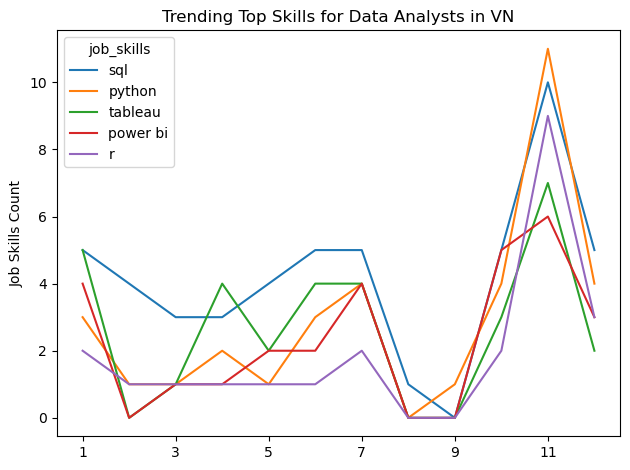

In [ ]:
df_DA_VN_pivot.iloc[:, :5].plot(kind='line') # get top 5 from job_skills column

plt.title('Trending Top Skills for Data Analysts in Vietnam')
plt.ylabel('Job Skills Count')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Job postings monthly total in Vietnam
DA_totals = df_DA_VN.groupby('job_posted_month_number').size()

DA_totals

job_posted_month_number
1     12
2      7
3      7
4      6
5      4
6      6
7      7
8      1
9      2
10     6
11    15
12     8
dtype: int64

In [ ]:
# divide 12 first 12 rows of df_DA_VN_pivot using .div
df_DA_VN_percent = df_DA_VN_pivot.iloc[:12].div(DA_totals/100, axis=0)

# changes month number to month name
df_DA_VN_percent = df_DA_VN_percent.reset_index()
df_DA_VN_percent['job_posted_month'] = df_DA_VN_percent['job_posted_month_number'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_VN_percent = df_DA_VN_percent.set_index('job_posted_month')
df_DA_VN_percent = df_DA_VN_percent.drop(columns='job_posted_month_number')

df_DA_VN_percent

job_skills,sql,python,tableau,power bi,r,excel,oracle,aws,sap,spark,...,julia,no-sql,qlik,snowflake,sharepoint,shell,t-sql,spreadsheet,windows,word
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,41.666667,25.000000,41.666667,33.333333,16.666667,8.333333,8.333333,0.000000,16.666667,8.333333,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,8.333333
Feb,57.142857,14.285714,0.000000,0.000000,14.285714,0.000000,14.285714,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
Mar,42.857143,14.285714,14.285714,14.285714,14.285714,14.285714,42.857143,14.285714,14.285714,14.285714,...,0.000000,0.000000,0.000000,14.285714,14.285714,0.000000,0.0,0.000000,0.0,0.000000
Apr,50.000000,33.333333,66.666667,16.666667,16.666667,16.666667,0.000000,0.000000,16.666667,16.666667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
May,100.000000,25.000000,50.000000,50.000000,25.000000,50.000000,0.000000,0.000000,0.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,25.0,0.000000
Jun,83.333333,50.000000,66.666667,33.333333,16.666667,33.333333,0.000000,16.666667,16.666667,0.000000,...,0.000000,0.000000,16.666667,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
Jul,71.428571,57.142857,57.142857,57.142857,28.571429,42.857143,14.285714,14.285714,14.285714,14.285714,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
Aug,100.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
Sep,0.000000,50.000000,0.000000,0.000000,0.000000,50.000000,0.000000,50.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


Text(0.5, 0, '')

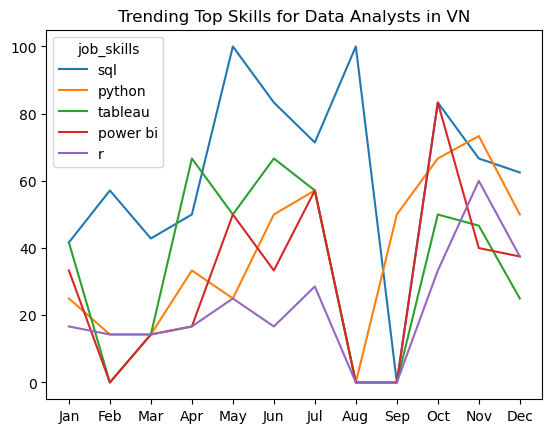

In [ ]:
df_plot = df_DA_VN_percent.iloc[:,:5]
sns.lineplot(data=df_plot,dashes=False,palette='tab10')

plt.title('Trending Top Skills for Data Analysts in Vietnam')
plt.ylabel('')
plt.xlabel('')